# Quantum Fourier Transform (QFT)

In this module, you will:
- Understand the mathematical definition of the **Quantum Fourier Transform (QFT)** and its action on general quantum states.
- Build the QFT circuit step-by-step using the QpiAI Quantum SDK — both **manually** with `Circuit` and via the high-level `QFT` class.
- Run experiments on a **simulator** and visualize the resulting quantum states.
- Learn how the **Inverse QFT** works and how it can be implemented.

## What is the Quantum Fourier Transform (QFT)?

The Quantum Fourier Transform acts on an $n$-qubit computational basis state $|x\rangle$, where $x \in \{0, 1, \dots, 2^n - 1\}$, and is defined as:

$$
\text{QFT} |x\rangle
= \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{2\pi i x k / 2^n} |k\rangle
$$

This is the quantum analogue of the classical discrete Fourier transform.

### Matrix Representation

The QFT can be written as an $N \times N$ unitary matrix $F_N$ where $N = 2^n$. Let $\omega = e^{2\pi i / N}$ be a primitive $N$-th root of unity. The matrix is given by:

$$
F_N = \frac{1}{\sqrt{N}}
\begin{pmatrix}
1 & 1 & 1 & \dots & 1 \\
1 & \omega & \omega^2 & \dots & \omega^{N-1} \\
1 & \omega^2 & \omega^4 & \dots & \omega^{2(N-1)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & \omega^{N-1} & \omega^{2(N-1)} & \dots & \omega^{(N-1)(N-1)}
\end{pmatrix}
$$

Each matrix element $F_{j,k}$ is given by $\frac{1}{\sqrt{N}} \omega^{jk}$.

### Action on a General State

For a general quantum state:

$$
|\psi\rangle = \sum_{x=0}^{2^n - 1} a_x |x\rangle
$$

the QFT produces:

$$
\text{QFT} |\psi\rangle
= \sum_{k=0}^{2^n - 1} \left( \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} a_x e^{2\pi i x k / 2^n} \right) |k\rangle
$$

The amplitudes are transformed by a discrete Fourier transform.

### Circuit Decomposition (Bit Representation)

Let the input be written in binary as:
$$x = x_1 x_2 \dots x_n$$

The QFT maps the input state as follows:

$$
|x_1 x_2 \dots x_n\rangle
\longrightarrow
\frac{1}{\sqrt{2^n}}
\bigotimes_{k=1}^{n}
\left( |0\rangle + e^{2\pi i (0.x_k x_{k+1} \dots x_n)} |1\rangle \right)
$$

where $0.x_k x_{k+1} \dots x_n$ denotes a binary fraction.

### What QFT does to $|0\rangle^n$

A particularly important case is when the input state is $|00\dots0\rangle$. In this case, $x=0$, and the definition simplifies:

$$
\text{QFT} |0\rangle^{\otimes n} = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} e^{0} |k\rangle = \frac{1}{\sqrt{2^n}} \sum_{k=0}^{2^n - 1} |k\rangle
$$

This creates a **uniform superposition** over all basis states, exactly like applying a Hadamard gate to each qubit.


## 1. Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [1]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## 2. SDK Primitives Used (This Module)

- `QFT` — high-level algorithm class that builds and runs the QFT circuit.
- `Circuit` — low-level circuit construction API (for manual QFT circuit building).
- **Gates:** `h` (Hadamard), `cp` (Controlled Phase), `swap` (Swap gate), `measure` (Measurement).
- **Circuit utilities:** `show()`, `list_gates()`, `to_qasm()`.
- **Execution:** `QFT.run(shots=..., device_name="QpiAI-QSV-Local") (Note: `experiment_name` is optional and only required for cloud executions)`.
- **Results:** `result.get_counts()`, `result.get_probabilities()`, `result.plot()`, `visualize()`.

We will first build the circuit **manually** to understand each stage, then use the high-level `QFT` class for convenience.

## 3. Building the QFT Circuit

### 3a. Manual Construction with `Circuit`

Let's build a **4-qubit** QFT circuit manually. The QpiAI SDK uses **little-endian** qubit ordering (where qubit 0 is the most significant bit). Because of this, we can construct the QFT by iterating in reverse order without needing to apply SWAP gates at the end.

=== Manual QFT Circuit (4 qubits) ===


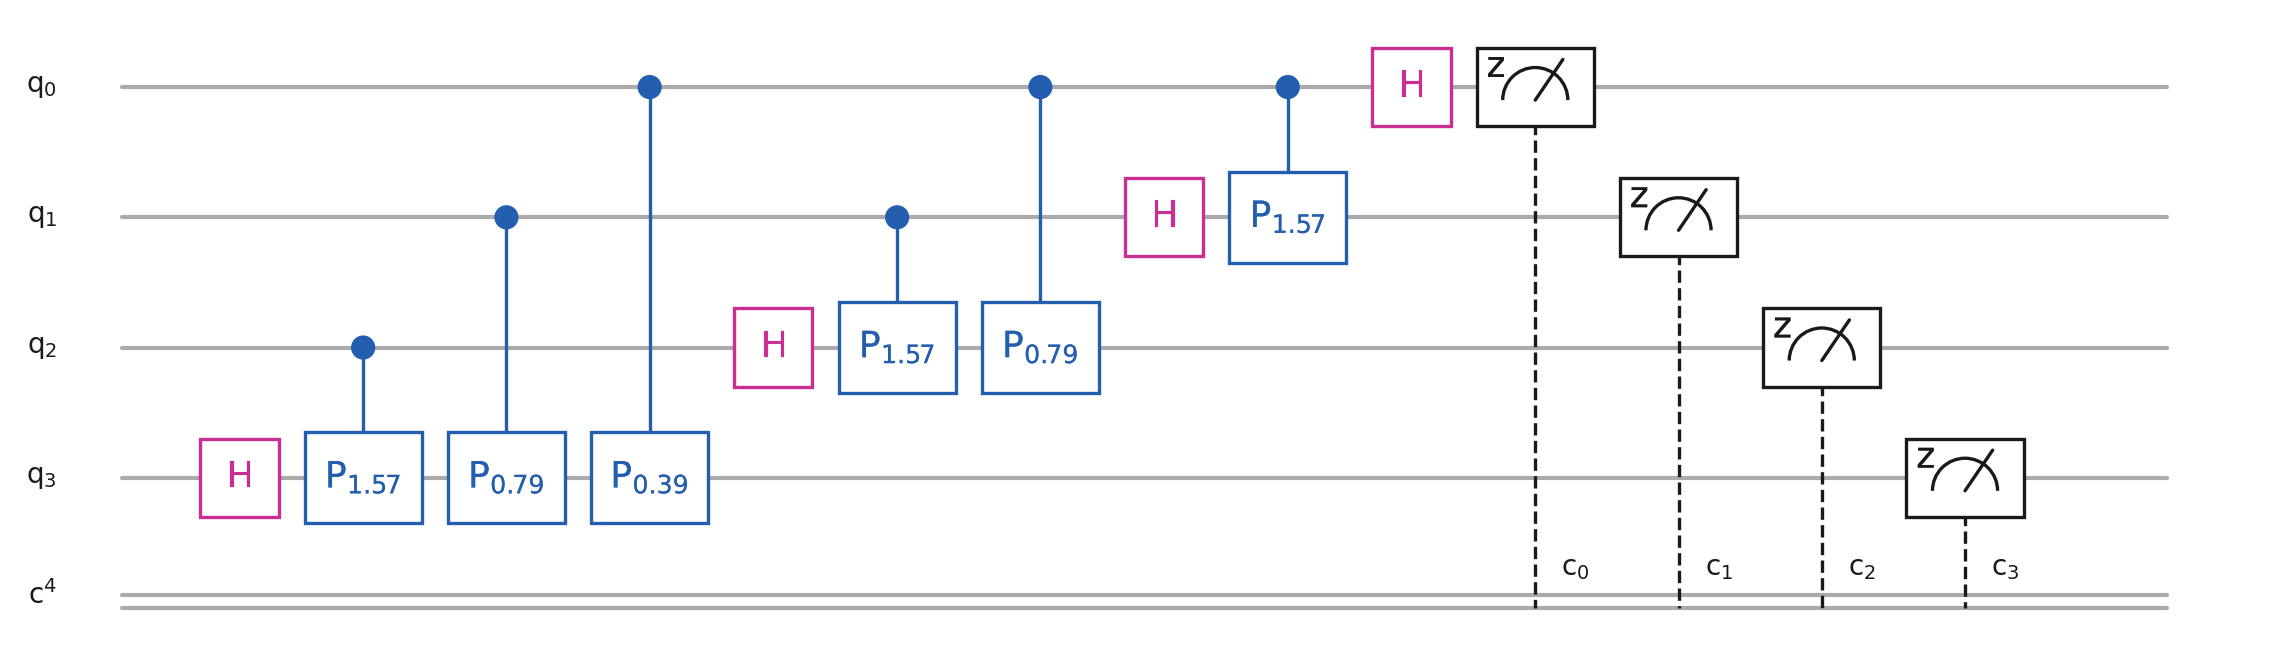

Gate stats: {'total_operations': 14, 'total_gates': 10, 'single_qubit_gates': 4, 'two_qubit_gates': 6, 'multi_qubit_gates': 0, 'clifford_gates': 4, 'non_clifford_gates': 6, 'parametric_gates': 6, 'measurements': 4, 'barriers': 0, 'gate_counts': {'H': 4, 'CP': 6, 'MEASURE': 4}}


In [2]:
import numpy as np
import math
from qpiai_quantum import Circuit

n = 4  # number of qubits
qc = Circuit(n, n)

# ── Little-Endian QFT Construction ──
# We iterate backwards from MSB to LSB. This avoids the need for SWAP gates.
for i in range(n - 1, -1, -1):
    # Apply Hadamard gate
    qc.h(i)
    
    # Apply controlled phase rotations
    for j in range(i - 1, -1, -1):
        # Controlled phase rotation by 2π/2^(i-j+1)
        theta = 2 * math.pi / (2 ** (i - j + 1))
        qc.cp(j, i, theta)

# ── Measure ──
for i in range(n):
    qc.measure(i, i)

print("=== Manual QFT Circuit (4 qubits) ===")
qc.show()
print("Gate stats:", qc.list_gates())

### 3b. High-Level Construction with `QFT`

The SDK provides a convenient `QFT` class that encapsulates the circuit construction automatically.

=== QFT Circuit (high-level, 4 qubits) ===


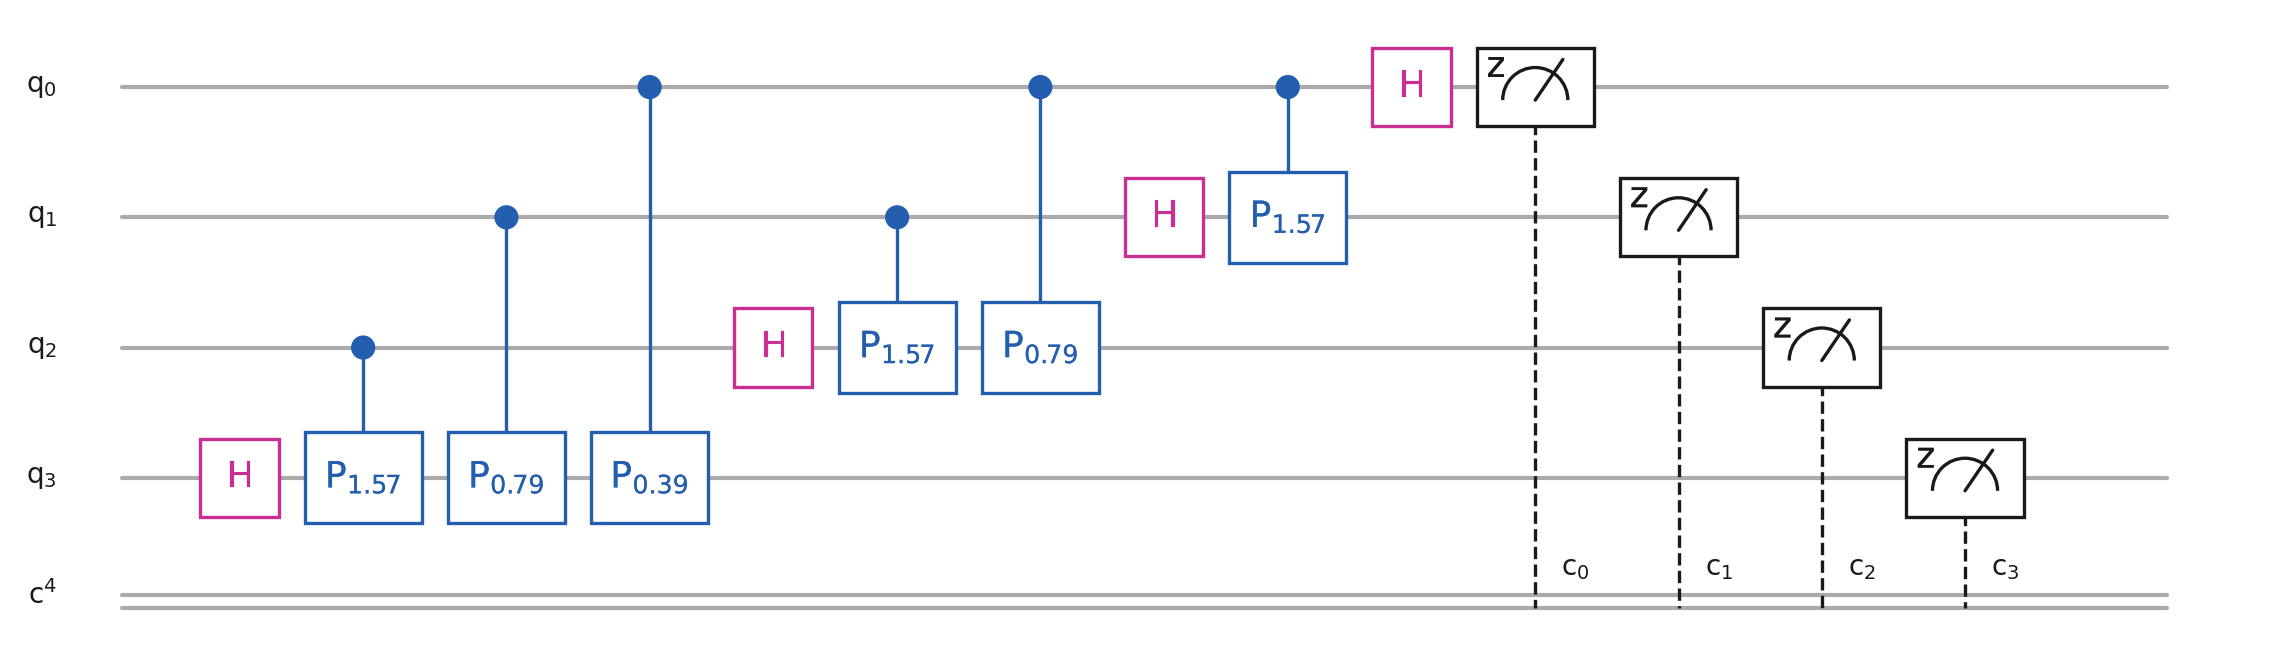

Gate stats: {'total_operations': 14, 'total_gates': 10, 'single_qubit_gates': 4, 'two_qubit_gates': 6, 'multi_qubit_gates': 0, 'clifford_gates': 4, 'non_clifford_gates': 6, 'parametric_gates': 6, 'measurements': 4, 'barriers': 0, 'gate_counts': {'H': 4, 'CP': 6, 'MEASURE': 4}}


In [3]:
from qpiai_quantum.algorithms import QFT

# Create QFT instance for 4 qubits
qft_algo = QFT(num_qubits=4, inverse=False)

# Build the circuit
qft_circuit = qft_algo.build_circuit()

print("=== QFT Circuit (high-level, 4 qubits) ===")
qft_circuit.show()
print("Gate stats:", qft_circuit.list_gates())

### 3c. QASM Representation

We can extract the underlying OPENQASM 2.0 code corresponding to our circuit:

In [4]:
qasm_code = qft_algo.to_qasm()
print(qasm_code)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[4];
creg c[4];
h q[3];
cp(1.5707963267948966) q[2], q[3];
cp(0.7853981633974483) q[1], q[3];
cp(0.39269908169872414) q[0], q[3];
h q[2];
cp(1.5707963267948966) q[1], q[2];
cp(0.7853981633974483) q[0], q[2];
h q[1];
cp(1.5707963267948966) q[0], q[1];
h q[0];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
measure q[3] -> c[3];


## 4. Experiment: Simulate and Verify

We will now execute the circuit. By default, the input state to the circuit is $|0000\rangle$. As discussed in the theory section, applying QFT to $|0000\rangle$ yields a uniform superposition. We expect every computational basis state (from `0000` to `1111`) to be measured with roughly equal probability — about $1/16 = 6.25\%$ each.

> **Simulator default:** `device_name="QpiAI-QSV-Local"`. To run on QPU hardware, change `device_name` to `"QpiAI-Indus-1"`.

First, let's estimate the execution cost.

In [5]:
# credits, label, backend_name = qft_algo.estimate_credits()
# print(f"Estimated cost: {credits} {label} on {backend_name}")

In [12]:
shots = 10_000
device_name='QpiAI-QSV-Local'

print(f"Executing on {device_name}...")
# Note: experiment_name is only required for cloud executions
result = qft_algo.run(shots=shots, device_name=device_name)



Executing on QpiAI-QSV-Simulator...


### Results Interpretation

Let's visualize the results:

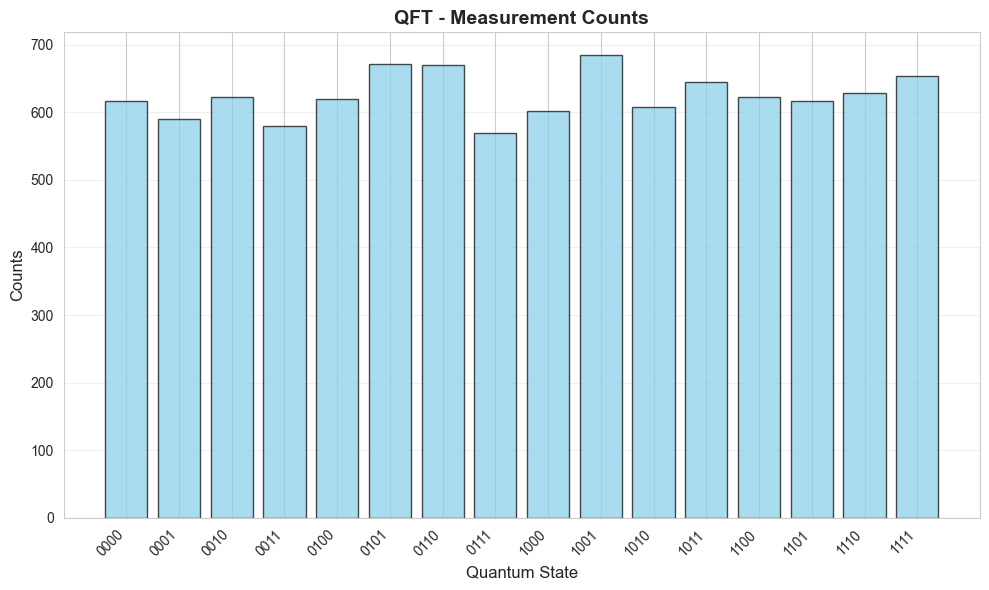

In [13]:
# Plotting the histogram of measurement counts
qft_algo.visualize(plot='histogram', result=result)

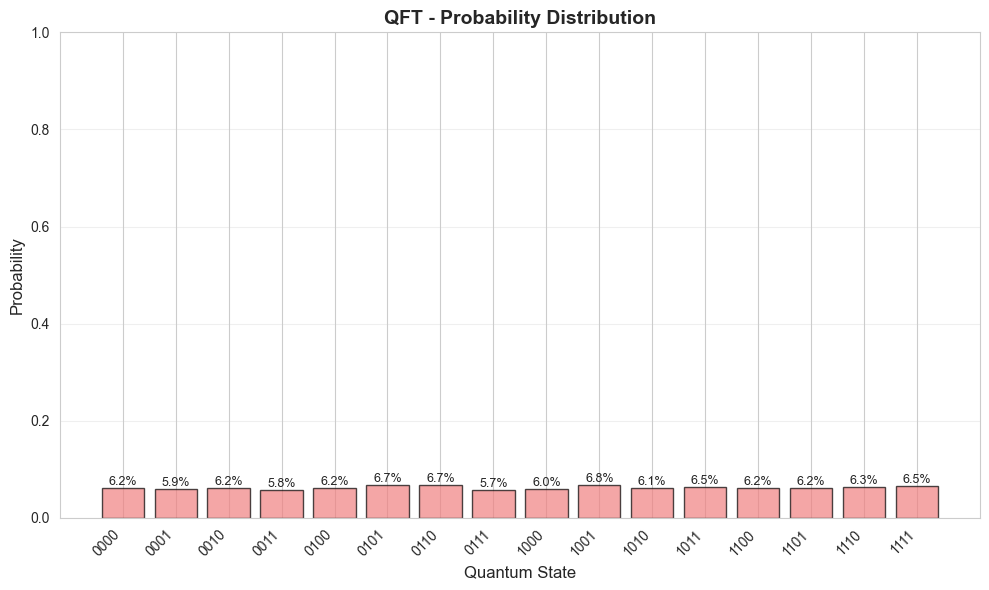

In [14]:
# Plotting the probability distribution
qft_algo.visualize(plot='probabilities', result=result)

As we can see, the outcome is a **uniform distribution**: all 16 states ($2^4$) have approximately the same probability ($\sim 0.0625$ or $6.25\%$). This confirms our mathematical prediction for the $\text{QFT}|0\rangle^{\otimes n}$ state.

## 5. Inverse QFT

The inverse Quantum Fourier Transform is given by:

$$
\text{QFT}^{-1} = \text{QFT}^\dagger
$$

and satisfies:

$$
\text{QFT}^{-1} \, \text{QFT} = I
$$

In practice, the inverse QFT is implemented by reversing the circuit and conjugating the phase rotations (i.e., using $-R_m$ gates).

We can generate this easily using the `inverse=True` argument:

=== Inverse QFT Circuit (4 qubits) ===


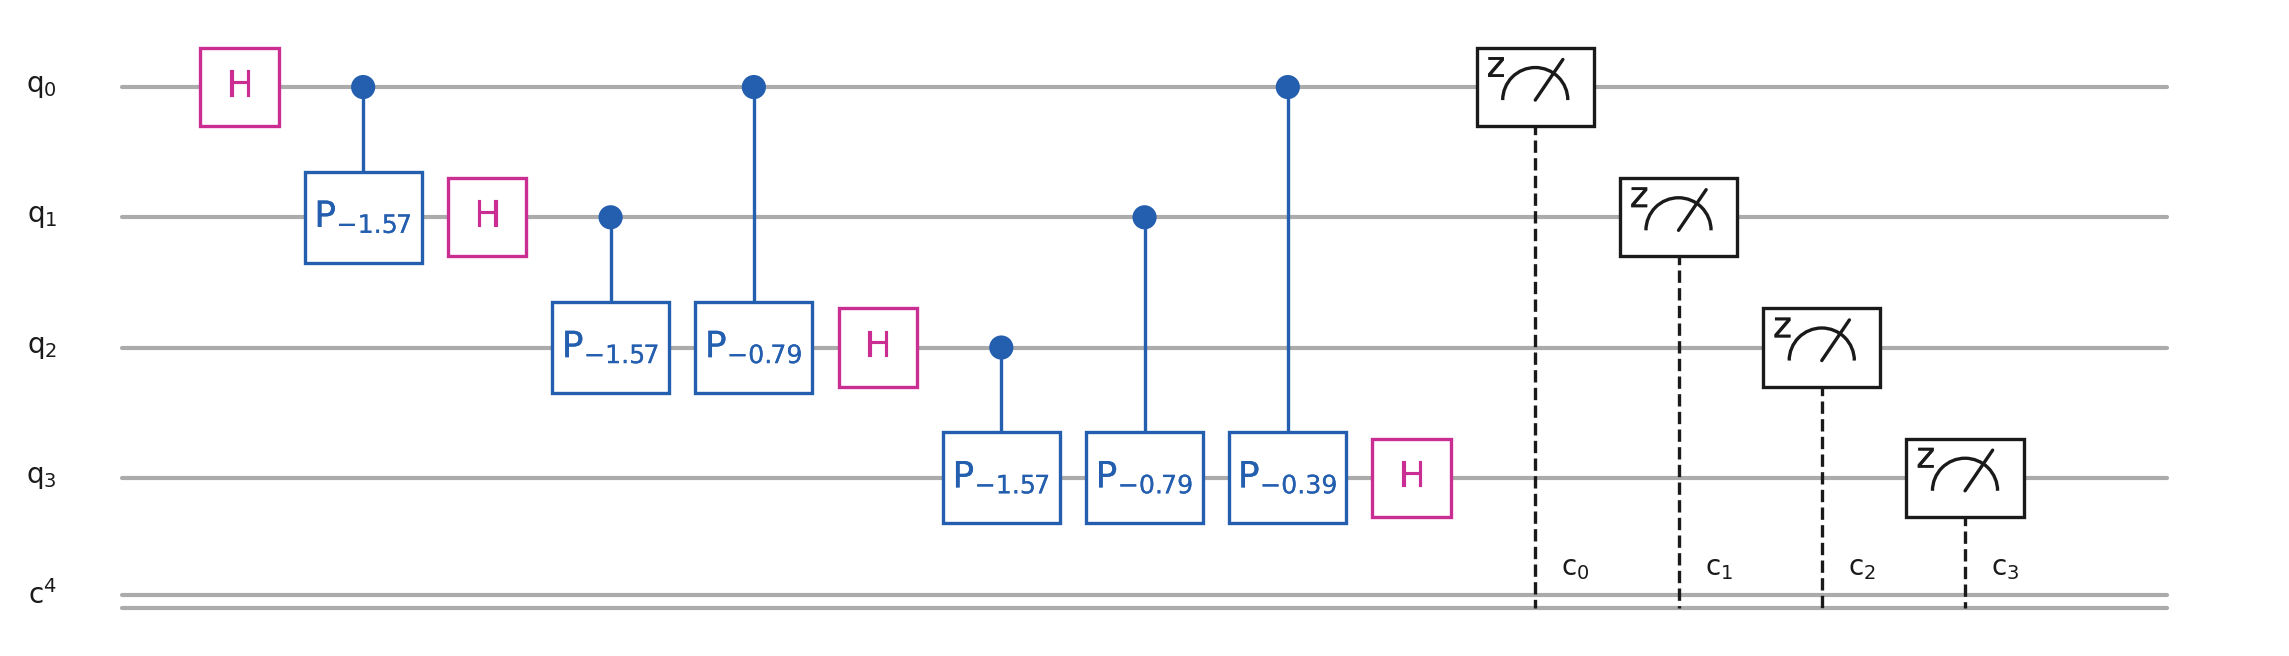

In [15]:
iqft_algo = QFT(num_qubits=4, inverse=True)
iqft_circuit = iqft_algo.build_circuit()

print("=== Inverse QFT Circuit (4 qubits) ===")
iqft_circuit.show()

## 6. Exercises

**Beginner:**

1. Try changing the `num_qubits` to 3. How many states do you expect to see in the histogram, and what should their probabilities be?

**Intermediate:**

2. Use the manual `Circuit` API to prepare the input state $|1000\rangle$ (by applying an $X$ gate to the first qubit) before applying the manual QFT circuit. Simulate this and observe the probability distribution. Does it still look uniform? Why or why not?

**Advanced:**

3. Prove that applying QFT followed by IQFT returns the system to its initial state. Build a circuit that combines both (by manually composing the instructions or using SDK composition methods if available) and run it. You should measure $|0000\rangle$ with 100% probability.

## 7. Key Takeaways

- The **Quantum Fourier Transform (QFT)** is the quantum analogue of the discrete Fourier transform and changes the basis of amplitudes.
- A key property is that $\text{QFT} |0\rangle^{\otimes n}$ creates a **uniform superposition** over all basis states.
- It can be implemented using $O(n^2)$ gates (Hadamard and controlled-phase gates), which is exponentially faster than the classical Fourier transform on $2^n$ amplitudes.
- The QFT is a vital subroutine in many advanced quantum algorithms, including **Shor's factoring algorithm**, **Phase estimation**, and **Order finding**.
- **Inverse QFT** reverses the transformation and is just as straightforward to set up via `QFT(num_qubits=n, inverse=True)`.

---
**Thank you for learning with QpiAI!**

In [16]:
import qpiai_quantum
print(f"QpiAI Quantum SDK version: {qpiai_quantum.__version__}")

QpiAI Quantum SDK version: 0.1.32
